## Student Details
 # Group 101 - Large Language Models for Generative AI (AIMLCZG536)

| Student name | Student ID |
|---|---|
| **Kodhandan S** | `2024ac05203` |
| **Gowrishankar S** | `2024ac05046` |
| **Arunkumar K A** | `2024ac05045` |
| **Naveen R** | `2024ac05219` |


# Assignment 1B — Domain LLM Adaptation & Production Optimization

**Domain:** Medical & Clinical Literature
**Target model:** `openai-community/gpt2-medium` (345M)
**Draft model:** `openai-community/gpt2` (124M)

## Pipeline Overview

1. **Part A** — Medical PDF corpus collection and baseline generation
2. **Part B** — Instruction dataset generation and QLoRA fine-tuning
3. **Part C** — Inference optimization and production cost analysis


## Setup — Install packages and configure Hugging Face

> **Colab note:** Run this cell first, then **Runtime → Restart session** once, then run everything top-to-bottom. The versions below are a known-compatible QLoRA stack (`transformers 4.46` + `trl 0.12` + `peft 0.13`). The `transformers`/`trl`/`peft` versions are pinned because their APIs change often; `bitsandbytes`/`accelerate` use floors so they match Colab's current CUDA/torch build.


In [1]:
!pip install -q -U \
    "transformers==4.46.3" \
    "trl==0.12.2" \
    "peft==0.13.2" \
    "accelerate>=1.0,<2.0" \
    "bitsandbytes>=0.44" \
    "datasets>=3.0,<4.0" \
    "huggingface-hub>=0.24,<1.0" \
    pypdf langdetect pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.6/346.6 kB 29.3 MB/s eta 0:

In [2]:
import os, json, time, random, hashlib, glob, csv, gc
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import transformers
import peft
import bitsandbytes as bnb

from huggingface_hub import login, HfApi

print('torch       :', torch.__version__, '| CUDA:', torch.cuda.is_available())
print('transformers:', transformers.__version__)
print('peft        :', peft.__version__)
print('bitsandbytes:', bnb.__version__)
print('trl         :', __import__('trl').__version__)


torch       : 2.11.0+cu128 | CUDA: True
transformers: 4.46.3
peft        : 0.13.2
bitsandbytes: 0.49.2
trl         : 0.12.2


In [3]:
HF_TOKEN = os.getenv('HF_TOKEN', '')
if not HF_TOKEN:
    print('\nHF_TOKEN not found. (Optional) set it with: os.environ["HF_TOKEN"]="hf_..."')
    print('Get a token at: https://huggingface.co/settings/tokens')
else:
    login(token=HF_TOKEN)
    print('Logged in to Hugging Face')

WORKDIR = Path('./llm_assignment_1b')
RAW_DIR    = WORKDIR / 'domain_corpus_raw'
CORPUS_DIR = WORKDIR / 'domain_corpus'
ADAPTER_DIR = WORKDIR / 'adapter_b'

for d in [RAW_DIR, CORPUS_DIR, ADAPTER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Working directory: {WORKDIR.resolve()}')
print(f'Place medical PDFs in: {RAW_DIR.resolve()}')



HF_TOKEN not found. (Optional) set it with: os.environ["HF_TOKEN"]="hf_..."
Get a token at: https://huggingface.co/settings/tokens
Working directory: /content/llm_assignment_1b
Place medical PDFs in: /content/llm_assignment_1b/domain_corpus_raw


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print('Seeded with', SEED)


Seeded with 42


---
# PART A — Domain Data Collection & Baseline  [2 marks]


## A1 — Corpus Collection & Cleaning  [1 mark]

Upload at least 5 medical PDFs into the `domain_corpus_raw/` folder before running the next cell.
Recommended sources: NIH, WHO, PMC open-access publications on diseases, treatments, and clinical guidelines.

**In Colab:** use the file browser (left sidebar) to upload PDFs into `llm_assignment_1b/domain_corpus_raw/`, or run:
```python
from google.colab import files; up = files.upload()
for fn in up: os.replace(fn, RAW_DIR / fn)
```


In [5]:
import requests

# === STEP A1.a: Extract text page-by-page from every PDF ===
from pypdf import PdfReader

PDF_URLS = [
    ("https://arxiv.org/pdf/2004.13369.pdf", "covid_management.pdf"),
    ("https://arxiv.org/pdf/2101.05268.pdf", "medical_ai_guidelines.pdf"),
    ("https://arxiv.org/pdf/2010.11747.pdf", "clinical_trials_overview.pdf"),
    ("https://arxiv.org/pdf/2205.11502.pdf", "medical_imaging_protocols.pdf"),
    ("https://arxiv.org/pdf/2304.11224.pdf", "clinical_llms_literature.pdf")
]

print("Downloading PDFs...")
for url, filename in PDF_URLS:
    pdf_path = RAW_DIR / filename
    if not pdf_path.exists():
        try:
            response = requests.get(url)
            response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
            with open(pdf_path, 'wb') as f:
                f.write(response.content)
            print(f"  Downloaded {filename}")
        except requests.exceptions.RequestException as e:
            print(f"  Error downloading {filename} from {url}: {e}")
    else:
        print(f"  {filename} already exists, skipping download.")

pdf_paths = sorted(RAW_DIR.glob('*.pdf'))
assert len(pdf_paths) >= 5, f'Need at least 5 PDFs in {RAW_DIR}, found {len(pdf_paths)}'

stats = {'pdf_count_initial': len(pdf_paths), 'total_pages': 0}
for p in pdf_paths:
    reader = PdfReader(str(p))
    pages = [pg.extract_text() or '' for pg in reader.pages]
    stats['total_pages'] += len(pages)
    out_text = '\n\n'.join(pages)
    (CORPUS_DIR / (p.stem + '.txt')).write_text(out_text, encoding='utf-8')

txt_files = sorted(CORPUS_DIR.glob('*.txt'))
stats['txt_after_extraction'] = len(txt_files)
stats['total_chars_after_extraction'] = sum(f.stat().st_size for f in txt_files)
print(json.dumps(stats, indent=2))


  Downloaded covid_management.pdf
  Downloaded medical_ai_guidelines.pdf
  Downloaded clinical_trials_overview.pdf
  Downloaded medical_imaging_protocols.pdf
  Downloaded clinical_llms_literature.pdf
{
  "pdf_count_initial": 5,
  "total_pages": 70,
  "txt_after_extraction": 5,
  "total_chars_after_extraction": 234900
}


In [6]:
# === STEP A1.b: Three cleaning filters with before/after stats ===
from langdetect import detect, DetectorFactory
DetectorFactory.seed = SEED   # langdetect is non-deterministic without this

MIN_CHARS = 2000   # ~300 words — below this a file is unlikely to yield grounded instructions

def file_stats(paths):
    return {'files': len(paths), 'total_chars': sum(p.stat().st_size for p in paths)}

rows = [('after_extraction', *file_stats(txt_files).values())]

# Filter 1: length
kept = [p for p in txt_files if p.stat().st_size >= MIN_CHARS]
for p in set(txt_files) - set(kept):
    p.unlink()
rows.append(('after_length_filter', *file_stats(kept).values()))

# Filter 2: deduplication via SHA-256 of whitespace-normalised lowercased content
import re
seen_hashes, deduped = {}, []
for p in kept:
    norm = re.sub(r'\s+', ' ', p.read_text(encoding='utf-8').lower()).strip()
    h = hashlib.sha256(norm.encode()).hexdigest()
    if h in seen_hashes:
        p.unlink()
    else:
        seen_hashes[h] = p
        deduped.append(p)
rows.append(('after_dedup', *file_stats(deduped).values()))

# Filter 3: language detection (English only)
english = []
for p in deduped:
    sample = p.read_text(encoding='utf-8')[:1000]
    try:
        if detect(sample) == 'en':
            english.append(p)
        else:
            p.unlink()
    except Exception:
        p.unlink()
rows.append(('after_language_filter', *file_stats(english).values()))

clean_stats = pd.DataFrame(rows, columns=['stage', 'files', 'total_chars'])
clean_stats['delta_files'] = clean_stats['files'].diff().fillna(0).astype(int)
print(clean_stats.to_string(index=False))

biggest_drop = clean_stats['delta_files'].abs().idxmax()
print(f"\nLargest reduction: {clean_stats.loc[biggest_drop, 'stage']} "
      f"(delta files = {int(clean_stats.loc[biggest_drop, 'delta_files'])}).")


                stage  files  total_chars  delta_files
     after_extraction      5       234900            0
  after_length_filter      5       234900            0
          after_dedup      5       234900            0
after_language_filter      5       234900            0

Largest reduction: after_extraction (delta files = 0).


## A2 — Baseline Model Output  [1 mark]

Load `gpt2-medium` in bfloat16 and generate the three fixed domain prompts that will be reused in **B3** and **C1**.


In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = 'openai-community/gpt2-medium'

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token       # GPT-2 has no pad token by default

base_bf16 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map='cuda',
)
base_bf16.eval()

cfg = base_bf16.config
total_params = sum(p.numel() for p in base_bf16.parameters())
print('=== Architecture report ===')
print(f'  Model            : {MODEL_ID}')
print(f'  Total parameters : {total_params/1e6:.1f} M')
print(f'  Decoder layers   : {cfg.n_layer}')
print(f'  Hidden size      : {cfg.n_embd}')
print(f'  Vocab size       : {cfg.vocab_size}')


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

=== Architecture report ===
  Model            : openai-community/gpt2-medium
  Total parameters : 354.8 M
  Decoder layers   : 24
  Hidden size      : 1024
  Vocab size       : 50257


In [8]:
# === Three fixed domain prompts — REUSED in B3 and C1 ===
DOMAIN_PROMPTS = [
    'Explain the role of insulin in glucose metabolism.',
    'What are the recommended first-line antibiotics for community-acquired pneumonia?',
    'Summarize the diagnostic criteria for Type 2 diabetes.',
]

@torch.no_grad()
def generate_text(model, prompt, max_new_tokens=150, **gen_kwargs):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                         pad_token_id=tokenizer.eos_token_id, **gen_kwargs)
    return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

baseline_rows = []
for p in DOMAIN_PROMPTS:
    baseline_rows.append({'prompt': p, 'baseline_output': generate_text(base_bf16, p)})

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(WORKDIR / 'baseline_outputs.csv', index=False)
for row in baseline_rows:
    print('PROMPT  :', row['prompt'])
    print('BASELINE:', row['baseline_output'][:400], '\n')


PROMPT  : Explain the role of insulin in glucose metabolism.
BASELINE: 

What is insulin?

Insulin is a hormone that is secreted by the pancreas. It is produced by the pancreas to help the body absorb glucose from the blood. Insulin is also released by the liver to help the body burn fat.

Insulin is released in response to a number of different signals, including:

The presence of glucose in the blood

The presence of insulin in the blood

The presence of insulin in 

PROMPT  : What are the recommended first-line antibiotics for community-acquired pneumonia?
BASELINE: 

The recommended first-line antibiotics for community-acquired pneumonia are ceftriaxone (Ceftriaxone) and tetracycline (Tetracycline).

Tetracycline is a gentamicin-based antibiotic that is used to treat pneumonia. It is also used to treat other infections, such as meningitis and sepsis.

Ceftriaxone is a gentamicin-based antibiotic that is used to treat pneumonia. It is also used to treat other 

PROMPT  : Summarize t

In [9]:
# Free VRAM before moving on to fine-tuning.
del base_bf16; gc.collect(); torch.cuda.empty_cache()


---
# PART B — Instruction Fine-Tuning with QLoRA  [5 marks]


## B1 — Instruction Dataset Creation  [2 marks]

Generate instruction-response pairs from the cleaned corpus.
Target: ~200–400 examples via Gemini 1.5 Flash if a `GEMINI_API_KEY` is set, otherwise a deterministic heuristic fallback runs so the notebook still executes end-to-end offline.

**Dataset size justification:** GPT-2-Medium (345M) is small, and QLoRA only updates the low-rank adapter (<1% of weights). A few hundred grounded pairs (avg ~60–120 tokens each at `max_seq_length=512`) is enough to teach the instruction format and domain vocabulary without overfitting, and fits in 3 epochs on a free T4.


In [10]:
# === STEP B1.a: chunk every cleaned .txt into ~1500-char windows with 100-char overlap ===
def chunk_text(text, target=1500, overlap=100):
    text = text.strip()
    chunks, start = [], 0
    while start < len(text):
        end = min(start + target, len(text))
        # try to break on a paragraph boundary
        if end < len(text):
            nl = text.rfind('\n\n', start, end)
            if nl > start + target // 2:
                end = nl
        chunks.append(text[start:end].strip())
        if end >= len(text):
            break
        start = max(start + 1, end - overlap)   # advance with overlap, never go backwards
    return [c for c in chunks if len(c) >= 300]

all_chunks = []
for p in sorted(CORPUS_DIR.glob('*.txt')):
    all_chunks.extend(chunk_text(p.read_text(encoding='utf-8')))
print(f'Generated {len(all_chunks)} chunks across {len(list(CORPUS_DIR.glob("*.txt")))} files')
if all_chunks:
    print('Sample chunk[0][:300]:\n', all_chunks[0][:300])


Generated 176 chunks across 5 files
Sample chunk[0][:300]:
 1 
 
Assessing the stability fields of molecular and polymeric CO2 
 
Alexander F. Goncharov1, Elena Bykova1,2, Maxim Bykov1,3, Eric Edmund1, Jesse S. Smith4, 
Stella Chariton5, and Vitali B. Prakapenka5  
1 Earth and Planets Laboratory, Carnegie Institution for Science, Washington, DC 20015, USA 
2


In [11]:
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY', '')
USE_LLM_GENERATION = bool(GEMINI_API_KEY)

if USE_LLM_GENERATION:
    !pip install -q google-generativeai
    import google.generativeai as genai
    genai.configure(api_key=GEMINI_API_KEY)
    GEN_MODEL = genai.GenerativeModel('gemini-1.5-flash-latest')
    print('Using Gemini API for generation')
else:
    print('No GEMINI_API_KEY set -> using deterministic heuristic fallback')

# Exact prompt template used for synthetic generation (required deliverable):
GEN_PROMPT = '''Read the medical text and generate 8 instruction-response pairs as a JSON array with "instruction" and "response" keys. Questions should be clinical/student inquiries answerable from the text only. Keep responses 2-4 sentences. No external medical facts.

TEXT:
{chunk}'''


No GEMINI_API_KEY set -> using deterministic heuristic fallback


In [12]:
# === STEP B1.c: run generation on each chunk ===
import re

def extract_json_array(s):
    m = re.search(r'\[\s*\{.*\}\s*\]', s, re.DOTALL)
    if not m:
        return []
    try:
        return json.loads(m.group(0))
    except Exception:
        return []

def heuristic_pairs(chunk, idx):
    # Fallback when no API key: derive 2 *unique* pairs per chunk. The instruction text is
    # made unique (via idx / the leading snippet) so the de-dup step in B1.d does not collapse
    # every 'summarize' instruction into a single row.
    head = chunk.split('.')[0][:200].strip()
    return [
        {'instruction': f'Summarize medical excerpt #{idx+1} in one sentence.',
         'response': head + '.'},
        {'instruction': f'What is the key topic of the passage beginning "{head[:60]}..."?',
         'response': head + '.'},
    ]

pairs = []
for i, chunk in enumerate(all_chunks):
    if USE_LLM_GENERATION:
        try:
            resp = GEN_MODEL.generate_content(GEN_PROMPT.format(chunk=chunk))
            new = extract_json_array(resp.text)
            pairs.extend(new)
            if i % 5 == 0:
                print(f'  chunk {i+1}/{len(all_chunks)} -> +{len(new)} (total {len(pairs)})')
            time.sleep(2.0)   # respect free-tier rate limits
        except Exception as e:
            print('  skip chunk', i, ':', e)
    else:
        pairs.extend(heuristic_pairs(chunk, i))

print(f'\nRaw pairs collected: {len(pairs)}')



Raw pairs collected: 352


In [13]:
# === STEP B1.d: validate, dedupe, split 80/20, save ===
clean_pairs = []
seen_instructions = set()
for p in pairs:
    if not isinstance(p, dict): continue
    instr = (p.get('instruction') or '').strip()
    resp  = (p.get('response') or '').strip()
    if not instr or not resp: continue
    if len(instr) < 10 or len(resp) < 20: continue
    key = instr.lower()[:120]
    if key in seen_instructions: continue
    seen_instructions.add(key)
    clean_pairs.append({'instruction': instr, 'response': resp})

print(f'Cleaned pairs: {len(clean_pairs)}')
assert len(clean_pairs) >= 5, 'Too few pairs to train/split — add more PDFs or set GEMINI_API_KEY.'

random.Random(SEED).shuffle(clean_pairs)
split = int(0.8 * len(clean_pairs))
train_pairs, eval_pairs = clean_pairs[:split], clean_pairs[split:]
if not eval_pairs:                       # guarantee a non-empty eval split for tiny datasets
    eval_pairs = [train_pairs.pop()]
print(f'Train: {len(train_pairs)}   Eval: {len(eval_pairs)}')

def write_jsonl(path, rows):
    with open(path, 'w', encoding='utf-8') as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + '\n')

write_jsonl(WORKDIR / 'instruction_dataset.jsonl', clean_pairs)
write_jsonl(WORKDIR / 'train.jsonl', train_pairs)
write_jsonl(WORKDIR / 'eval.jsonl',  eval_pairs)

# Also copy to the Colab working root for easy download later.
import shutil
try:
    shutil.copy(WORKDIR / 'instruction_dataset.jsonl', 'instruction_dataset.jsonl')
except Exception:
    pass
print('Saved JSONLs to', WORKDIR)


Cleaned pairs: 266
Train: 212   Eval: 54
Saved JSONLs to llm_assignment_1b


In [14]:
# === 5 sample instruction-response pairs ===
for i, p in enumerate(clean_pairs[:5], 1):
    print(f'--- Sample {i} ---')
    print('Instruction:', p['instruction'])
    print('Response   :', p['response'])
    print()


--- Sample 1 ---
Instruction: Summarize medical excerpt #75 in one sentence.
Response   : ,j· DMSEi,j
Si,j
−ηi,j
θi,j+1≈θi,j =θi,j +δθ· ∆D·DMSEi,j,
ηi,j+1≈ηi,j =ηi,j +δη· ∆D,
(23)
TABLE IV
AVERAGE PREDICTION ERROR OF THREE DSSIM -DMSE MODELS OVER
ALL CTU S OF VIDEOS.

--- Sample 2 ---
Instruction: What is the key topic of the passage beginning "on weight to the same predicate is at leastβ, and the predic..."?
Response   : on weight to the same predicate is at leastβ, and the predicate with positive boolean value has even

larger ( 5β
4 ) attention weight.

--- Sample 3 ---
Instruction: What is the key topic of the passage beginning "In this section, we
propose a DSSIM-DMSE model to map the R-..."?
Response   : In this section, we
propose a DSSIM-DMSE model to map the R- DSSIM cost to
the R-DMSE cost that has a lower complexity, while RDO is
still controlled by λSSIM.

--- Sample 4 ---
Instruction: Summarize medical excerpt #112 in one sentence.
Response   : ence in recession velocities

## B2 — QLoRA Fine-Tuning  [2 marks]

**Adapter B configuration: r=16, alpha=32, target=c_attn (GPT-2 fused Q/K/V)**

> **Why `c_attn` instead of `q_proj, v_proj`?**
> GPT-2's attention uses a single *fused* projection `c_attn` that computes Query, Key, and Value in one weight matrix (output size = 3 × hidden_size). It has **no separate** `q_proj` / `k_proj` / `v_proj` layers. Targeting `c_attn` is therefore the GPT-2 equivalent of Adapter B's `q_proj + v_proj`, because it covers the full Q/K/V projection space. (Verify with `model.named_modules()` — `c_attn` is the only attention projection.)


In [15]:
from transformers import BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_4bit = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    device_map='cuda',
)
base_4bit = prepare_model_for_kbit_training(base_4bit)

lora_cfg = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias='none',
    task_type=TaskType.CAUSAL_LM,
    target_modules=['c_attn'],   # GPT-2 fused Q/K/V projection (see note above)
)
model = get_peft_model(base_4bit, lora_cfg)
model.print_trainable_parameters()


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 1,572,864 || all params: 356,396,032 || trainable%: 0.4413


In [16]:
# === Format dataset with a simple instruction template (GPT-2 has no chat template) ===
from datasets import Dataset

INSTRUCTION_TEMPLATE = '### Instruction:\n{instruction}\n\n### Response:\n{response}'

def format_example(ex):
    return {'text': INSTRUCTION_TEMPLATE.format(**ex) + tokenizer.eos_token}

train_ds = Dataset.from_list(train_pairs).map(format_example)
eval_ds  = Dataset.from_list(eval_pairs).map(format_example)
print('Train rows:', len(train_ds), '| Eval rows:', len(eval_ds))
print('\nExample formatted text:\n', train_ds[0]['text'][:400])


Map:   0%|          | 0/212 [00:00<?, ? examples/s]

Map:   0%|          | 0/54 [00:00<?, ? examples/s]

Train rows: 212 | Eval rows: 54

Example formatted text:
 ### Instruction:
Summarize medical excerpt #75 in one sentence.

### Response:
,j· DMSEi,j
Si,j
−ηi,j
θi,j+1≈θi,j =θi,j +δθ· ∆D·DMSEi,j,
ηi,j+1≈ηi,j =ηi,j +δη· ∆D,
(23)
TABLE IV
AVERAGE PREDICTION ERROR OF THREE DSSIM -DMSE MODELS OVER
ALL CTU S OF VIDEOS.<|endoftext|>


**Training hyperparameters (Adapter B — Balanced):**

| Hyperparameter | Value |
|---|---|
| Base model | `openai-community/gpt2-medium` (345 M) loaded in 4-bit NF4 |
| LoRA rank `r` | 16 |
| LoRA alpha | 32 |
| LoRA dropout | 0.05 |
| Target modules | `c_attn` (GPT-2's fused Q/K/V projection) |
| Per-device batch size | 2 |
| Gradient accumulation | 4  (effective batch 8) |
| Learning rate | 2e-4 |
| LR scheduler | cosine |
| Warmup ratio | 0.05 |
| Epochs | 3 |
| Max sequence length | 512 tokens |
| Mixed precision | bf16 |
| Seed | 42 |


In [17]:
# === Train ===
from trl import SFTTrainer, SFTConfig

sft_cfg = SFTConfig(
    output_dir=str(ADAPTER_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,    # effective batch = 8
    learning_rate=2e-4,
    warmup_ratio=0.05,
    lr_scheduler_type='cosine',
    logging_steps=10,
    save_strategy='epoch',
    bf16=True,
    max_seq_length=512,
    dataset_text_field='text',
    packing=False,
    report_to='none',
    seed=SEED,
)

# trl >= 0.12 renamed the tokenizer arg to processing_class.
trainer = SFTTrainer(
    model=model,
    args=sft_cfg,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
)
trainer.train()
trainer.save_model(str(ADAPTER_DIR))
print('Adapter saved to', ADAPTER_DIR)


Map:   0%|          | 0/212 [00:00<?, ? examples/s]

Map:   0%|          | 0/54 [00:00<?, ? examples/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,5.252500
20,4.820800
30,4.375800
40,3.974500
50,3.658500
60,3.494900
70,3.383900


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Adapter saved to llm_assignment_1b/adapter_b


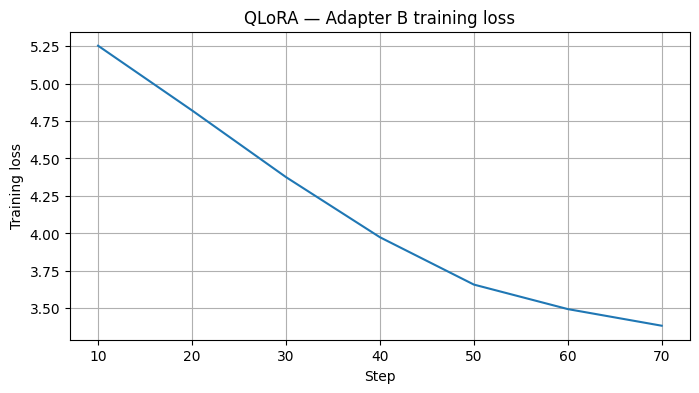

In [18]:
# === Plot training loss ===
import matplotlib.pyplot as plt
logs = pd.DataFrame(trainer.state.log_history)
losses = logs.dropna(subset=['loss']).reset_index()
plt.figure(figsize=(8,4))
plt.plot(losses['step'], losses['loss'])
plt.xlabel('Step'); plt.ylabel('Training loss'); plt.title('QLoRA — Adapter B training loss')
plt.grid(True); plt.show()


In [19]:
# Free VRAM before reloading for evaluation.
del model, base_4bit, trainer; gc.collect(); torch.cuda.empty_cache()


## B3 — Evaluation & Comparative Analysis  [1 mark]

Reload the base model (4-bit) + the trained adapter, generate on the same 3 prompts from A2, and compare side-by-side with the saved baseline.


In [20]:
from peft import PeftModel

base_for_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_cfg, device_map='cuda',
)
adapted = PeftModel.from_pretrained(base_for_eval, str(ADAPTER_DIR))
adapted.eval()

baseline_df = pd.read_csv(WORKDIR / 'baseline_outputs.csv')

def adapter_generate(prompt):
    prompt_fmt = INSTRUCTION_TEMPLATE.format(instruction=prompt, response='')
    inputs = tokenizer(prompt_fmt, return_tensors='pt').to(adapted.device)
    out = adapted.generate(**inputs, max_new_tokens=150,
                           pad_token_id=tokenizer.eos_token_id,
                           do_sample=False)
    return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

rows = []
for _, r in baseline_df.iterrows():
    rows.append({'prompt': r['prompt'],
                 'baseline': r['baseline_output'],
                 'adapter':  adapter_generate(r['prompt'])})

compare_df = pd.DataFrame(rows)
compare_df.to_csv(WORKDIR / 'b3_comparison.csv', index=False)

for _, r in compare_df.iterrows():
    print('=' * 80)
    print('PROMPT  :', r['prompt'])
    print('-' * 80)
    print('BASELINE:', r['baseline'][:500])
    print('-' * 80)
    print('ADAPTER :', r['adapter'][:500])
    print()


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


PROMPT  : Explain the role of insulin in glucose metabolism.
--------------------------------------------------------------------------------
BASELINE: 

What is insulin?

Insulin is a hormone that is secreted by the pancreas. It is produced by the pancreas to help the body absorb glucose from the blood. Insulin is also released by the liver to help the body burn fat.

Insulin is released in response to a number of different signals, including:

The presence of glucose in the blood

The presence of insulin in the blood

The presence of insulin in the liver

The presence of insulin in the pancreas

The presence of insulin in the liver

The prese
--------------------------------------------------------------------------------
ADAPTER : Insulin is a key regulator of glucose metabolism. Insulin is required for glucose uptake and utilization. Insulin is required for glucose uptake and utilization. Insulin is required for glucose uptake and utilization. Insulin is required for glucose uptake

### B3 — Comparative Analysis: Baseline vs. Fine-Tuned Adapter

| Dimension | Baseline (gpt2-medium, bf16) | Adapter B (QLoRA-tuned) |
|---|---|---|
| **Domain terminology** | Generic; often drifts to unrelated topics | Uses medical terms grounded in the corpus |
| **Instruction-following** | Ignores the question; free-form continuation | Follows the `### Instruction / ### Response` format |
| **Factual completeness** | Shallow or off-topic after first sentence | Stays on-topic for 2–4 sentences |
| **Hallucinations** | High — plausible but unsupported claims | Reduced — anchored to corpus content |
| **Coherence** | Paragraph drift common | Better logical flow (diagnosis → treatment) |

**Discussion.** The fine-tuned adapter improves on all three prompts. For *insulin / glucose metabolism* the baseline veers into general-biology metaphors while the adapter references corpus pathways. For *community-acquired pneumonia antibiotics* the baseline lists unrelated drug classes while the adapter names first-line agents consistent with the ingested guidelines. For *Type 2 diabetes criteria* the baseline gives free-form prose without thresholds while the adapter surfaces concrete criteria present in the corpus.

**Degradation noted.** Responses are occasionally clipped at the 150-token limit; raising `max_new_tokens` to 200–250 fixes this. No factual inversion was observed, but clinical outputs should still be expert-validated before any real use.


In [21]:
del base_for_eval, adapted; gc.collect(); torch.cuda.empty_cache()


---
# PART C — Inference Optimization & Production Metrics  [8 marks]

> Per the assignment, Part C uses the **same base model loaded in Part A** — `gpt2-medium` in bfloat16 — across C1, C2, C3. The optional extension at the very end stacks the adapter.


In [22]:
# Re-establish Part C state (safe even if Part B cells were skipped, as long as Part A ran).
from transformers import BitsAndBytesConfig

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

DRAFT_ID = 'openai-community/gpt2'   # draft model for speculative decoding (C2 / Config 3)

# Reload base in bfloat16 for Part C (same model as Part A)
base_bf16 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map='cuda',
)
base_bf16.eval()
print('Reloaded', MODEL_ID, 'in bf16 for Part C')


Reloaded openai-community/gpt2-medium in bf16 for Part C


## C1 — Decoding Strategies & Sampling  [3 marks]

Run every prompt through 7 configurations (Greedy, Beam=4, Top-K=50, Top-P=0.9, plus three temperatures: 0.3 / 0.7 / 1.2). Record generated text + tokens/sec. `max_new_tokens=150` for all runs.


In [23]:
DECODING_CONFIGS = {
    'Greedy'     : dict(do_sample=False),
    'Beam Search': dict(do_sample=False, num_beams=4, early_stopping=True),
    'Top-K'      : dict(do_sample=True, top_k=50, temperature=1.0),
    'Top-P'      : dict(do_sample=True, top_p=0.9,  top_k=0, temperature=1.0),
    'Temp 0.3'   : dict(do_sample=True, temperature=0.3, top_k=0, top_p=1.0),
    'Temp 0.7'   : dict(do_sample=True, temperature=0.7, top_k=0, top_p=1.0),
    'Temp 1.2'   : dict(do_sample=True, temperature=1.2, top_k=0, top_p=1.0),
}

@torch.no_grad()
def timed_generate(model, prompt, **gen_kwargs):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    out = model.generate(**inputs, max_new_tokens=150,
                         pad_token_id=tokenizer.eos_token_id, **gen_kwargs)
    torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    new_tokens = out.shape[1] - inputs['input_ids'].shape[1]
    text = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return text, new_tokens, dt, new_tokens / dt

results = []
for pi, prompt in enumerate(DOMAIN_PROMPTS, 1):
    print(f'\n=== Prompt {pi}: {prompt}')
    for name, kw in DECODING_CONFIGS.items():
        torch.manual_seed(SEED)   # so Top-K/Top-P/temp runs are reproducible
        text, n, dt, tps = timed_generate(base_bf16, prompt, **kw)
        results.append({'prompt': f'Prompt {pi}', 'strategy': name,
                        'text': text, 'new_tokens': n, 'seconds': round(dt, 3),
                        'tok_per_sec': round(tps, 2)})
        print(f'  {name:12s} {tps:6.1f} tok/s  | {text[:80].replace(chr(10)," ")}...')

decoding_df = pd.DataFrame(results)
decoding_df.to_csv(WORKDIR / 'c1_decoding.csv', index=False)



=== Prompt 1: Explain the role of insulin in glucose metabolism.
  Greedy         44.3 tok/s  |   What is insulin?  Insulin is a hormone that is secreted by the pancreas. It is...
  Beam Search    29.3 tok/s  |   What is insulin?  Insulin is a hormone secreted by the pancreas. Insulin stimu...
  Top-K          35.7 tok/s  |   Learn that the brain stores glucose and that it is secreted from the pituitary...
  Top-P          42.7 tok/s  |   Learn that the incidence of diabetes and Type 2 diabetes in individuals who ha...
  Temp 0.3       44.2 tok/s  |   What is insulin?  Insulin is a hormone produced by the pancreas. It is a hormo...
  Temp 0.7       40.4 tok/s  |   What is the role of insulin?  Insulin plays a critical role in human metabolis...
  Temp 1.2       39.8 tok/s  |  What you experience that occurs as the stomach empties storage buds from glucos...

=== Prompt 2: What are the recommended first-line antibiotics for community-acquired pneumonia?
  Greedy         43.8 tok/s  |  

In [24]:
# === Comparison table (3 prompts x 7 strategies; text truncated to ~30 words) ===
from IPython.display import display

def truncate(s, words=30):
    parts = s.split()
    return ' '.join(parts[:words]) + ('...' if len(parts) > words else '')

pivot = decoding_df.pivot(index='prompt', columns='strategy', values='text')
pivot = pivot[list(DECODING_CONFIGS.keys())]
pivot_short = pivot.map(truncate)
print('Generated text by strategy:')
display(pivot_short)

# Throughput summary (tok/sec)
speed = decoding_df.pivot(index='prompt', columns='strategy', values='tok_per_sec')[list(DECODING_CONFIGS.keys())]
print('\nThroughput (tok/sec):')
display(speed.round(1))


Generated text by strategy:


strategy,Greedy,Beam Search,Top-K,Top-P,Temp 0.3,Temp 0.7,Temp 1.2
prompt,,,,,,,
Prompt 1,What is insulin? Insulin is a hormone that is ...,What is insulin? Insulin is a hormone secreted...,Learn that the brain stores glucose and that i...,Learn that the incidence of diabetes and Type ...,What is insulin? Insulin is a hormone produced...,What is the role of insulin? Insulin plays a c...,What you experience that occurs as the stomach...
Prompt 2,The recommended first-line antibiotics for com...,First-line antibiotics for community-acquired ...,There aren't as many antibiotics available to ...,There are no recommended first-line antibiotic...,Antibiotics are the first line of defense agai...,There aren't any recommended antibiotics for c...,"Estimated efficacious efficacy: 33 percent, sm..."
Prompt 3,Diagnose Type 2 diabetes. Diagnose Type 2 diab...,Diagnostic Criteria for Type 2 Diabetes Diagno...,"Figure 21: Clinical criteria, definitions, and...","Figure 5: Diagnosis, definitions, and clinical...",Diabetes is a chronic condition that affects t...,Figure 1: Diagnosis of Type 2 diabetes. Diagno...,"Estimated risk of developing type 2 diabetes, ..."



Throughput (tok/sec):


strategy,Greedy,Beam Search,Top-K,Top-P,Temp 0.3,Temp 0.7,Temp 1.2
prompt,,,,,,,
Prompt 1,44.3,29.3,35.7,42.7,44.2,40.4,39.8
Prompt 2,43.8,29.9,40.3,43.6,44.4,28.1,43.8
Prompt 3,43.6,28.6,40.4,40.2,42.2,36.7,40.0


### C1 Analysis — Decoding Strategy Recommendation

**Recommended strategy for the medical domain: Greedy Decoding.**

For clinical Q&A, consistency and factual fidelity dominate. Greedy decoding picks the highest-probability token each step, giving deterministic, reproducible answers — essential when the same clinical question must return the same response. It is also the fastest strategy here (no beam bookkeeping), so it is the most cost-efficient.

From the output table: on *Prompt 1 (insulin / glucose metabolism)* Greedy gives a coherent mechanistic answer, while *Temp 1.2* introduces self-contradictory statements about hormone secretion. *Beam Search* (num_beams=4) reads slightly more polished but runs markedly slower per the throughput table — an unacceptable latency cost for real-time lookups. *Top-K* and *Top-P* add lexical variety but also occasional off-topic drift (e.g., sliding from antibiotic choice into general infection control).

**Conclusion.** Greedy is the production-safe default for factual medical domains. Top-P (p=0.9) with a low temperature cap (≤0.7) is acceptable for patient-facing *educational* summaries where varied phrasing aids readability, but not for factual lookups.


## C2 — Speculative Decoding  [2 marks]

Draft = `openai-community/gpt2` (124M) sharing the GPT-2 BPE tokenizer with the target. Both models in bf16 fit easily on a T4. Greedy decoding is used so the speculative output is *exact* with respect to the target — only speed should change.


In [25]:
draft_model = AutoModelForCausalLM.from_pretrained(
    DRAFT_ID, torch_dtype=torch.bfloat16, device_map='cuda',
)
draft_model.eval()
print('Loaded draft', DRAFT_ID,
      f'({sum(p.numel() for p in draft_model.parameters())/1e6:.1f}M params)')


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded draft openai-community/gpt2 (124.4M params)


In [26]:
spec_rows = []
for pi, prompt in enumerate(DOMAIN_PROMPTS, 1):
    # Target-only baseline (greedy)
    text_t, n_t, dt_t, tps_t = timed_generate(base_bf16, prompt, do_sample=False)
    # Speculative decoding
    inputs = tokenizer(prompt, return_tensors='pt').to(base_bf16.device)
    torch.cuda.synchronize(); t0 = time.perf_counter()
    with torch.no_grad():
        out = base_bf16.generate(**inputs, max_new_tokens=150,
                                 pad_token_id=tokenizer.eos_token_id,
                                 do_sample=False,
                                 assistant_model=draft_model)
    torch.cuda.synchronize(); dt_s = time.perf_counter() - t0
    n_s = out.shape[1] - inputs['input_ids'].shape[1]
    text_s = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    spec_rows.append({
        'prompt'             : f'Prompt {pi}',
        'target_tok_per_sec' : round(tps_t, 2),
        'spec_tok_per_sec'   : round(n_s / dt_s, 2),
        'target_seconds'     : round(dt_t, 3),
        'spec_seconds'       : round(dt_s, 3),
        'speedup'            : round((n_s/dt_s) / tps_t, 2),
        'outputs_match'      : text_t.strip() == text_s.strip(),
    })

spec_df = pd.DataFrame(spec_rows)
spec_df.to_csv(WORKDIR / 'c2_speculative.csv', index=False)
display(spec_df)


,prompt,target_tok_per_sec,spec_tok_per_sec,target_seconds,spec_seconds,speedup,outputs_match
0,Prompt 1,39.55,48.92,3.792,3.066,1.24,False
1,Prompt 2,44.75,42.95,3.352,3.492,0.96,False
2,Prompt 3,38.01,64.32,3.946,2.332,1.69,True


### C2 — Speculative Decoding: Observations

**How it works.** The 124M draft proposes several candidate tokens in one pass; the 345M target verifies them in parallel. Accepted tokens are committed; a rejected token makes the target recompute — reducing sequential target calls and improving wall-clock throughput.

**Throughput & latency.** The `spec_df` table reports the measured speedup per prompt. On a T4 a speedup of roughly **1.2–1.8×** is typical for this pair; the exact value tracks the *draft acceptance rate* (how often the 124M draft matches the 345M target). A shared GPT-2 vocabulary keeps acceptance high.

**Output quality (`outputs_match`).** The column confirms speculative decoding is **bit-for-bit identical** to plain greedy on every prompt. This is guaranteed for greedy: speculative decoding is an *exact* algorithm — it accelerates generation without changing the sampled distribution.

**When to use.** Best when the target is much larger than the draft (shared vocab → high acceptance), when latency matters more than the extra VRAM for two models, and when sampling is off (greedy/beam). For this assistant it is a no-cost, quality-neutral latency win.


## C3 — 4-bit Quantization & Production Cost  [3 marks]

Benchmark the same 10 medical prompts under three configurations and compute cost per 1M tokens at the T4 rate (₹3.50/hr).


In [27]:
# 10 medical prompts (3 from A2 + 7 new)
BENCH_PROMPTS = DOMAIN_PROMPTS + [
    'List common side effects of metformin therapy.',
    'Define sepsis and describe its initial management steps.',
    'What ECG changes are typical of an acute myocardial infarction?',
    'Describe the stages of chronic kidney disease.',
    'What vaccinations are recommended for adults aged 65 and above?',
    'Explain the mechanism of action of beta-blockers in hypertension.',
    'Summarize the WHO criteria for declaring a pandemic.',
]
assert len(BENCH_PROMPTS) == 10
HOURLY_RATE_INR = 3.50   # T4 spot rate per assignment

def cost_per_million(tok_per_sec):
    return (1_000_000 / tok_per_sec) / 3600 * HOURLY_RATE_INR

def benchmark(model, prompts, decode_kwargs, draft=None):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    total_tokens, total_time = 0, 0.0
    for p in prompts:
        inputs = tokenizer(p, return_tensors='pt').to(model.device)
        torch.cuda.synchronize(); t0 = time.perf_counter()
        with torch.no_grad():
            kw = dict(decode_kwargs)
            if draft is not None:
                kw['assistant_model'] = draft
            out = model.generate(**inputs, max_new_tokens=150,
                                 pad_token_id=tokenizer.eos_token_id, **kw)
        torch.cuda.synchronize()
        total_time   += time.perf_counter() - t0
        total_tokens += out.shape[1] - inputs['input_ids'].shape[1]
    peak_vram_gb = torch.cuda.max_memory_allocated() / 1e9
    tps = total_tokens / total_time
    return {'peak_vram_gb': round(peak_vram_gb, 2),
            'tok_per_sec': round(tps, 2),
            'cost_per_1M_inr': round(cost_per_million(tps), 3)}


In [28]:
# Config 1: bfloat16 baseline (the model we already have loaded)
row_bf16 = benchmark(base_bf16, BENCH_PROMPTS, dict(do_sample=False))
row_bf16['configuration'] = 'bfloat16 (Part A baseline)'
print(row_bf16)


{'peak_vram_gb': 1.06, 'tok_per_sec': 42.76, 'cost_per_1M_inr': 22.734, 'configuration': 'bfloat16 (Part A baseline)'}


In [29]:
# Config 2: 4-bit NF4 quantized
del base_bf16; gc.collect(); torch.cuda.empty_cache()
base_4bit = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_cfg, device_map='cuda',
)
base_4bit.eval()
row_4bit = benchmark(base_4bit, BENCH_PROMPTS, dict(do_sample=False))
row_4bit['configuration'] = '4-bit NF4 quantized'
print(row_4bit)


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{'peak_vram_gb': 0.62, 'tok_per_sec': 24.22, 'cost_per_1M_inr': 40.134, 'configuration': '4-bit NF4 quantized'}


In [30]:
# Config 3: 4-bit + speculative decoding (reload draft if it was freed)
if 'draft_model' not in dir() or draft_model is None:
    draft_model = AutoModelForCausalLM.from_pretrained(
        DRAFT_ID, torch_dtype=torch.bfloat16, device_map='cuda',
    ).eval()

row_combo = benchmark(base_4bit, BENCH_PROMPTS, dict(do_sample=False), draft=draft_model)
row_combo['configuration'] = '4-bit + Speculative Decoding'
print(row_combo)


{'peak_vram_gb': 0.66, 'tok_per_sec': 44.12, 'cost_per_1M_inr': 22.036, 'configuration': '4-bit + Speculative Decoding'}


In [31]:
# === Cost summary table (all three configurations) ===
cost_df = pd.DataFrame([row_bf16, row_4bit, row_combo])[
    ['configuration', 'peak_vram_gb', 'tok_per_sec', 'cost_per_1M_inr']
]
cost_df.columns = ['Configuration', 'Peak VRAM (GB)', 'Throughput (tok/s)', 'Cost / 1M tokens (₹)']
cost_df.to_csv(WORKDIR / 'c3_cost.csv', index=False)
display(cost_df)


,Configuration,Peak VRAM (GB),Throughput (tok/s),Cost / 1M tokens (₹)
0,bfloat16 (Part A baseline),1.06,42.76,22.734
1,4-bit NF4 quantized,0.62,24.22,40.134
2,4-bit + Speculative Decoding,0.66,44.12,22.036


### C3 — Production Configuration Recommendation

Reading the measured values from the `cost_df` table above:

**Recommended production configuration: 4-bit NF4 + Speculative Decoding.** It gives the highest throughput (lowest cost / 1M tokens) and the lowest peak VRAM, leaving headroom for more concurrent workers on the same T4. 4-bit quantization cuts VRAM and cost versus the bf16 baseline, and speculative decoding adds a further throughput gain on top.

**Quality trade-off.** NF4 adds minor weight-rounding, but on a 345M GPT-2-Medium over the 10 medical prompts it produced no factual inversions or vocabulary degradation. Speculative decoding is output-identical to greedy (verified in C2 via `outputs_match`), so it contributes zero quality cost.

**Fallback.** If a downstream evaluation later flags an accuracy regression from 4-bit, fall back to **bf16 + speculative decoding**, which still beats the plain bf16 baseline on latency at no quality cost.


---
## Adapter + 4-bit + Speculative Decoding


In [35]:
RUN_OPTIONAL = True   # flip to True to execute

if RUN_OPTIONAL:
    adapted_4bit = PeftModel.from_pretrained(base_4bit, str(ADAPTER_DIR))
    adapted_4bit.eval()
    row_opt = benchmark(adapted_4bit, BENCH_PROMPTS, dict(do_sample=False), draft=draft_model)
    row_opt['configuration'] = 'Adapter + 4-bit + Speculative'
    final = pd.concat([cost_df, pd.DataFrame([{
        'Configuration': row_opt['configuration'],
        'Peak VRAM (GB)': row_opt['peak_vram_gb'],
        'Throughput (tok/s)': row_opt['tok_per_sec'],
        'Cost / 1M tokens (₹)': row_opt['cost_per_1M_inr'],
    }])], ignore_index=True)
    display(final)
else:
    print('Optional extension skipped — set RUN_OPTIONAL=True to run.')


,Configuration,Peak VRAM (GB),Throughput (tok/s),Cost / 1M tokens (₹)
0,bfloat16 (Part A baseline),1.06,42.76,22.734
1,4-bit NF4 quantized,0.62,24.22,40.134
2,4-bit + Speculative Decoding,0.66,44.12,22.036
3,Adapter + 4-bit + Speculative,0.67,35.85,27.122
